In [1]:
%load_ext autoreload
%autoreload 2

import ezy_seq as ezy
#import ezy_seq.load 
import scanpy as sc
import pandas as pd
import os
import pathlib
import matplotlib.pyplot as plt
import napari
import glob
import numpy as np
import anndata as ad
from scipy import sparse
from matplotlib.path import Path as MPath  # For polygon operations (matplotlib Path)
cell_type_col_name='RNA_Rerun_w_CosMx_Profile_Cell.Typing.InSituType.1_1_clusters'
import random
random.seed(0)


c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [9]:
def import_anndata_from_seurat_csvs(
      input_dir,
      *,
      x_filename="normalized_counts.csv",
      counts_filename="raw_counts.csv",
      counts_layer_name="counts",
      var_filename="features_counts.csv",
      obs_filename="cell_metadata.csv",
      coords_key="spatial_fov",
      coords_filename="coords_xy.csv",
      pca_key="X_pca",
      pca_filename="pca.csv",
      umap_key="X_umap",
      umap_filename="umap.csv",
      import_other_obsm=True,
      other_obsm_exclude_files=(),
      sparsify=True,
      verbose=True,
  ):
      """
      Reconstruct an AnnData object from the CSVs written by
      export_anndata_for_seurat.

      Reads (where present):
        - normalized_counts.csv -> adata.X
        - raw_counts.csv        -> adata.layers[counts_layer_name]
        - features_counts.csv   -> adata.var
        - cell_metadata.csv     -> adata.obs
        - coords_xy.csv         -> adata.obsm[coords_key]
        - pca.csv               -> adata.obsm[pca_key]
        - umap.csv              -> adata.obsm[umap_key]
        - any other *.csv       -> adata.obsm[<stem>]  (if import_other_obsm)

      Returns the rebuilt AnnData.
      """
      if verbose:
          print("Reconstructing AnnData from CSV files...")
          print(f"Input directory: {input_dir}")

      def _exists(name):
          return os.path.exists(os.path.join(input_dir, name))

      def _read_matrix_csv(path):
          df = pd.read_csv(path, index_col=0)
          return df.values, df.index, df.columns

      # 1) X (required)
      if not _exists(x_filename):
          raise FileNotFoundError(
              f"Missing {x_filename} in {input_dir} — cannot build AnnData without X."
          )
      X, x_index, x_cols = _read_matrix_csv(os.path.join(input_dir, x_filename))
      if sparsify:
          X = sparse.csr_matrix(X)
      if verbose:
          print(f"✓ Loaded X from {x_filename}: {X.shape} (cells x genes)")

      # 2) var / obs (aligned to X)
      if _exists(var_filename):
          var = pd.read_csv(os.path.join(input_dir, var_filename), index_col=0).reindex(x_cols)
          if verbose:
              print(f"✓ Loaded var: {var.shape}")
      else:
          var = pd.DataFrame(index=x_cols)
          if verbose:
              print(f"⚠ {var_filename} not found; using empty var")

      if _exists(obs_filename):
          obs = pd.read_csv(os.path.join(input_dir, obs_filename), index_col=0).reindex(x_index)
          if verbose:
              print(f"✓ Loaded obs: {obs.shape}")
      else:
          obs = pd.DataFrame(index=x_index)
          if verbose:
              print(f"⚠ {obs_filename} not found; using empty obs")

      adata = ad.AnnData(X=X, obs=obs, var=var)

      # 3) counts layer
      if _exists(counts_filename):
          counts, c_index, c_cols = _read_matrix_csv(os.path.join(input_dir, counts_filename))
          if list(c_index) != list(adata.obs_names) or list(c_cols) != list(adata.var_names):
              counts = (pd.DataFrame(counts, index=c_index, columns=c_cols)
                        .reindex(index=adata.obs_names, columns=adata.var_names)
                        .values)
          if sparsify:
              counts = sparse.csr_matrix(counts)
          adata.layers[counts_layer_name] = counts
          if verbose:
              print(f"✓ Loaded counts -> layers['{counts_layer_name}']: {counts.shape}")
      elif verbose:
          print(f"⚠ {counts_filename} not found; no counts layer added")

      # 4) obsm — special keys
      def _load_obsm(filename, key, expected_cols=None):
          if not _exists(filename):
              if verbose:
                  print(f"⚠ {filename} not found; skipping obsm['{key}']")
              return
          df = pd.read_csv(os.path.join(input_dir, filename),
  index_col=0).reindex(adata.obs_names)
          if expected_cols is not None:
              cols = [c for c in expected_cols if c in df.columns]
              if cols:
                  df = df[cols]
          adata.obsm[key] = df.values
          if verbose:
              print(f"✓ Loaded {filename} -> obsm['{key}']: {df.shape}")

      _load_obsm(coords_filename, coords_key, expected_cols=["x", "y"])
      _load_obsm(pca_filename, pca_key)
      _load_obsm(umap_filename, umap_key, expected_cols=["UMAP_1", "UMAP_2"])

      # 5) obsm — any other *.csv in the directory
      if import_other_obsm:
          reserved = {
              x_filename, counts_filename, var_filename, obs_filename,
              coords_filename, pca_filename, umap_filename,
              *other_obsm_exclude_files,
          }
          for fname in sorted(os.listdir(input_dir)):
              if not fname.endswith(".csv") or fname in reserved:
                  continue
              key = os.path.splitext(fname)[0]
              df = pd.read_csv(os.path.join(input_dir, fname), index_col=0)
              if df.shape[0] != adata.n_obs:
                  if verbose:
                      print(f"⚠ {fname}: rows {df.shape[0]} != n_obs {adata.n_obs}; skipping")
                  continue
              df = df.reindex(adata.obs_names)
              adata.obsm[key] = df.values
              if verbose:
                  print(f"✓ Loaded {fname} -> obsm['{key}']: {df.shape}")

      if verbose:
          print("\n✓ AnnData reconstruction complete!")
          print(adata)

      return adata


base_ad = import_anndata_from_seurat_csvs(
    r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t\base"
)
r'''up = import_anndata_from_seurat_csvs(
    r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t\up"
)
down = import_anndata_from_seurat_csvs(
    r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t\down"
)
'''

Reconstructing AnnData from CSV files...
Input directory: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t\base
✓ Loaded X from normalized_counts.csv: (639756, 1000) (cells x genes)
✓ Loaded var: (1000, 9)
✓ Loaded obs: (639756, 165)
✓ Loaded counts -> layers['counts']: (639756, 1000)
✓ Loaded coords_xy.csv -> obsm['spatial_fov']: (639756, 2)
⚠ pca.csv not found; skipping obsm['X_pca']
⚠ umap.csv not found; skipping obsm['X_umap']
✓ Loaded spatial.csv -> obsm['spatial']: (639756, 2)

✓ AnnData reconstruction complete!
AnnData object with n_obs × n_vars = 639756 × 1000
    obs: 'cell_type', 'RNA_Rerun_w_CosMx_Profile_Cell.Typing.InSituType.1_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', '

'up = import_anndata_from_seurat_csvs(\n    r"C:\\Users\\woods\\OneDrive - University of Missouri\\General - Lin Brain Lab - Ogrp\\Carter Woods\\CosMx_Processing\\Manuscript\\csvs_20g_100t\\up"\n)\ndown = import_anndata_from_seurat_csvs(\n    r"C:\\Users\\woods\\OneDrive - University of Missouri\\General - Lin Brain Lab - Ogrp\\Carter Woods\\CosMx_Processing\\Manuscript\\csvs_20g_100t\\down"\n)\n'

In [27]:
adata_full = sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\fully_updated.h5ad")

In [2]:
cell_type_col_name='RNA_Rerun_w_CosMx_Profile_Cell.Typing.InSituType.1_1_clusters'
file_path = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\sample_info_napari_comp.xlsx"
meta_dictionary=ezy.read_dictionary(file_path)
adatas=ezy.load.cosmx(r"E:\Carter-Woods\CosMx export\manuscript_CosMx_ref")




Scanning subdirectories for 'flatFiles'...
Found 5 dataset(s) to process.
Processing: 120Land323DY
Processing: 367Rand215L
Processing: 217Rand144_2L
Processing: 368R
Processing: 118Band1182L


In [3]:
cell_type_col_name='RNA_Rerun_w_CosMx_Profile_Cell.Typing.InSituType.1_1_clusters'
annotate_adatas=ezy.apply_annotation_manu_version(adatas,meta_dictionary,cell_type_key=cell_type_col_name)
norm_adatas=ezy.filter_and_normalize(annotate_adatas                      
    ,min_gene_cnt=20
    ,min_t_cnt=100)#Zhao et al. (2025), Nature Communications,
adata_full=ezy.combine_adatas( r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\raw_20g_100t_no00.h5ad",norm_adatas)

***********************
Processing: 120Land323DY
***********************
***********************
Processing: 367Rand215L
***********************
***********************
Processing: 217Rand144_2L
***********************
***********************
Processing: 368R
***********************
***********************
Processing: 118Band1182L
***********************
Updated order being applied


c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_simple.py:176

In [4]:

def load_polys(fp):
    if not os.path.exists(fp): return []
    df = pd.read_csv(fp)
    # pick axis columns (accept 'axis-0'/'axis-1' or first two 'axis*' matches)
    axes = ['axis-0','axis-1']
    xcol,ycol = axes[1], axes[0]
    df = df.dropna(subset=[xcol,ycol])
    return [g[[ycol,xcol]].to_numpy() for _,g in df.groupby('index')]


def load_all_polygons(project_folder):

    project_folder_ = pathlib.Path(project_folder)
    polygons = {}
    print('here')
    for fp in project_folder_.rglob("*-polygons.csv.gz"):
        slide_name_ = fp.stem.replace("-polygons", "")
        slide_name = slide_name_.replace(".csv", "")
        polygons[slide_name] = pd.read_csv(fp)
    return polygons


# Example usage:
project_folder = r"E:\Carter-Woods\CosMx export\10_31_export"
polygons_dict = load_all_polygons(project_folder)


sample_list=[['120L','323DY'],['368R'],['1182L','118B'],['217R','144_2L'],['367R','215L']]
layer_folders=['120Land323DY','368R','118Band1182L','217Rand144_2L','367Rand215L']
polygons=[]
for folder in layer_folders:
    polygons.append(polygons_dict[folder])


here


In [6]:
adata_full.write_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\raw_20g_100t_no00.h5ad")

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
from matplotlib.path import Path

# adata_full = sc.read_h5ad(r"PATH_TO_YOUR_FILE")
base = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project"

dfs = []
categories=['Cerebellum.csv', 'Cortex.csv', 'Hippocampus.csv', 'Olfactory.csv', 'Unassigned.csv', 'Striatum.csv']
# Loop through your sample lists and corresponding folders
for samples, polygon_df, slide_folder in zip(sample_list, polygons, layer_folders):
    
    # 1. Create the subset for the current slide/batch
    s_df = adata_full[adata_full.obs['sample_ID'].isin(samples)].copy()
    
    # Initialize the NEW 'napari_region' column
    # Default to 'Unassigned' (or 'Background')
    s_df.obs['napari_region'] = 'Unassigned'

    # 2. Set up coordinates
    # Note: Napari exports usually include axis-0 (Y) and axis-1 (X).
    # We need to ensure we compare (X, Y) cells to (X, Y) vertices.
    # Assuming obsm['spatial_fov'] is standard Scanpy (X, Y):
    cell_xy = s_df.obsm['spatial_fov'][:, :2] 

    # 3. Find all CSV files in the current slide folder
    search_path = os.path.join(base, slide_folder, "*.csv")
    found_csvs = glob.glob(search_path)

    if not found_csvs:
        print(f"No CSVs found in {slide_folder}")

    for fp in found_csvs:
        # Extract the region name from the filename (e.g., 'Plaque_A.csv' -> 'Plaque_A')
        file_name = os.path.basename(fp)
        print(samples)
        if file_name not in categories:
            print(f"Skipping: {file_name} not in categories")
            continue

        print(fp)
        region_name = os.path.splitext(file_name)[0]

        df = pd.read_csv(fp)
        
        # Detect axis columns: axis-1 is X, axis-0 is Y in Napari
        xcol = 'axis-0' if 'axis-0' in df.columns else None
        ycol = 'axis-1' if 'axis-1' in df.columns else None
        
        if xcol is None or ycol is None:
            print(f"Skipping {fp}: columns need to be axis-0 and axis-1")
            continue

        # Group vertices by polygon index and test points
        hit_mask = np.zeros(len(cell_xy), dtype=bool)
        
        for _, g in df.groupby('index'):
            # Stack as (X, Y) to match cell_xy
            verts = np.column_stack((g[xcol].to_numpy(dtype=float), g[ycol].to_numpy(dtype=float)))
            
            if len(verts) < 3:  # skip degenerate polygons
                continue
            
            p = Path(verts)
            # Update mask: true if point is in ANY of the polygons for this region type
            hit_mask |= p.contains_points(cell_xy)

        # 4. Assign the region name ONLY to the 'napari_region' column
        if hit_mask.any():
            s_df.obs.loc[hit_mask, 'napari_region'] = region_name
            print(f"  -> Assigned '{region_name}': {hit_mask.sum()} cells")

    # Append processed subset to list
    print(f"Finished {slide_folder} — Region distribution:\n{s_df.obs['napari_region'].value_counts()}\n")
    dfs.append(s_df)

# Concatenate back together
adata_full = sc.concat(dfs, join='outer', axis=0, merge="first", index_unique='-')

# Optional: Convert new column to categorical for easier plotting later
adata_full.obs['napari_region'] = adata_full.obs['napari_region'].astype('category')

# Save
#save_path = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\Methods_Manu\napari_labeled.h5ad"
#adata_full.write_h5ad(save_path)
#print(f"Saved to {save_path}")

['120L', '323DY']
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\120Land323DY\Cerebellum.csv
  -> Assigned 'Cerebellum': 32535 cells
['120L', '323DY']
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\120Land323DY\Cortex.csv
  -> Assigned 'Cortex': 48986 cells
['120L', '323DY']
Skipping: CosMx cells.csv not in categories
['120L', '323DY']
Skipping: CosMx polygons.csv not in categories
['120L', '323DY']
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\120Land323DY\Hippocampus.csv
  -> Assigned 'Hippocampus': 7468 cells
['120L', '323DY']
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\120Land323DY\Olfactory.csv
  -> Assigned 'Olfactory': 12568 cells
['120L', '323DY']
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\

In [14]:
import imageio.v2 as imageio
import napari
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Base directory for your project
base = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project"
adata_obj=base_ad
for slide in adata_obj.obs['slide_ID'].unique():
    # Create subset for the current slide
    s_df = adata_obj[adata_obj.obs['slide_ID'] == slide].copy()
    
    print(f"Processing slide: {slide}")
    
    # --- 1. PREPARE COLORS (Your original code) ---
    unique_clusters = s_df.obs['quint_region'].unique()
    cmap = plt.get_cmap('tab20') 
    colors_list = [cmap(i) for i in np.linspace(0, 1, len(unique_clusters))]
    
    cluster_color_dict = dict(zip(unique_clusters, colors_list))
    assigned_colors = s_df.obs['quint_region'].astype(object).map(cluster_color_dict).tolist()

    # --- 2. INITIALIZE VIEWER & ADD POINTS (Your original code) ---
    viewer = napari.Viewer()
    
    # Base cells
    viewer.add_points(
        s_df.obsm['spatial_fov'], 
        size=100,
        border_width=0.0,
        face_color=assigned_colors,
        name="CosMx cells"
    )



napari.run()

Processing slide: 120Land323DY
Processing slide: 368R
Processing slide: 118Band1182L
Processing slide: 217Rand144_2L
Processing slide: 367Rand215L


In [7]:
import os
import numpy as np
import pandas as pd
from scipy import sparse

def export_anndata_for_seurat(
    adata,
    output_dir,
    *,
    counts_layer_candidates=("counts", "raw"),
    x_filename="normalized_counts.csv",
    counts_filename="raw_counts.csv",
    var_filename="features_counts.csv",
    obs_filename="cell_metadata.csv",
    coords_key="spatial_fov",
    coords_filename="coords_xy.csv",
    pca_key="X_pca",
    pca_filename="pca.csv",
    umap_key="X_umap",
    umap_filename="umap.csv",
    export_other_obsm=True,
    other_obsm_exclude=("spatial_fov", "X_pca", "X_umap"),
    verbose=True,
):
    """
    Export an AnnData object to CSVs for reconstruction in R/Seurat.

    Writes:
      - raw_counts.csv: cells x genes from chosen counts layer (or X fallback)
      - normalized_counts.csv: cells x genes from X
      - features_counts.csv: adata.var
      - cell_metadata.csv: adata.obs
      - coords_xy.csv: adata.obsm[coords_key] -> columns ['x','y'] if available
      - pca.csv, umap.csv if available
      - optional: any other obsm matrices (each to <key>.csv)

    Returns dict of written file paths.
    """
    os.makedirs(output_dir, exist_ok=True)
    written = {}

    def _to_dense(mat):
        if sparse.issparse(mat):
            return mat.toarray()
        # some arrays expose .toarray without being scipy sparse
        if hasattr(mat, "toarray"):
            return mat.toarray()
        return np.asarray(mat)

    if verbose:
        print("Exporting AnnData to CSV files...")
        print(f"Output directory: {output_dir}")

    # 1) Choose raw counts source
    counts_source = None
    for lyr in counts_layer_candidates:
        if lyr in getattr(adata, "layers", {}):
            counts_source = lyr
            counts = adata.layers[lyr]
            if verbose:
                print(f"Using '{lyr}' layer for raw counts")
            break
    if counts_source is None:
        counts = adata.X
        if verbose:
            print("⚠ Warning: No counts layer found; using X for raw_counts (may be logged/normalized)")

    counts = _to_dense(counts)
    counts_df = pd.DataFrame(counts, index=adata.obs_names, columns=adata.var_names)
    counts_path = os.path.join(output_dir, counts_filename)
    counts_df.to_csv(counts_path)
    written["counts"] = counts_path
    if verbose:
        print(f"✓ Exported counts: {counts_df.shape} (cells x genes) -> {counts_path}")

    # 1b) Export X (normalized/log)
    x_data = _to_dense(adata.X)
    x_df = pd.DataFrame(x_data, index=adata.obs_names, columns=adata.var_names)
    x_path = os.path.join(output_dir, x_filename)
    x_df.to_csv(x_path)
    written["X"] = x_path
    if verbose:
        print(f"✓ Exported normalized data (X): {x_df.shape} (cells x genes) -> {x_path}")

    # 2) var
    var_path = os.path.join(output_dir, var_filename)
    adata.var.to_csv(var_path)
    written["var"] = var_path
    if verbose:
        print(f"✓ Exported gene metadata (var): {adata.var.shape} -> {var_path}")

    # 3) obs
    obs_path = os.path.join(output_dir, obs_filename)
    adata.obs.to_csv(obs_path)
    written["obs"] = obs_path
    if verbose:
        print(f"✓ Exported cell metadata (obs): {adata.obs.shape} -> {obs_path}")

    # 4) spatial coords
    if coords_key in getattr(adata, "obsm", {}):
        coords = np.asarray(adata.obsm[coords_key])
        if coords.shape[1] < 2:
            if verbose:
                print(f"⚠ Warning: '{coords_key}' found but has <2 columns; skipping coords export.")
        else:
            coords_df = pd.DataFrame(coords[:, :2], index=adata.obs_names, columns=["x", "y"])
            coords_path = os.path.join(output_dir, coords_filename)
            coords_df.to_csv(coords_path)
            written["coords"] = coords_path
            if verbose:
                print(f"✓ Exported spatial coordinates ({coords_key}): {coords_df.shape} -> {coords_path}")
    else:
        if verbose:
            print(f"⚠ Warning: '{coords_key}' not found in obsm")

    # 5) PCA
    if pca_key in getattr(adata, "obsm", {}):
        pca = np.asarray(adata.obsm[pca_key])
        pca_df = pd.DataFrame(pca, index=adata.obs_names, columns=[f"PC{i+1}" for i in range(pca.shape[1])])
        pca_path = os.path.join(output_dir, pca_filename)
        pca_df.to_csv(pca_path)
        written["pca"] = pca_path
        if verbose:
            print(f"✓ Exported PCA ({pca_key}): {pca_df.shape} -> {pca_path}")
    else:
        if verbose:
            print(f"⚠ PCA not found in obsm ('{pca_key}')")

    # 6) UMAP
    if umap_key in getattr(adata, "obsm", {}):
        umap = np.asarray(adata.obsm[umap_key])
        if umap.shape[1] < 2:
            if verbose:
                print(f"⚠ Warning: '{umap_key}' found but has <2 columns; skipping UMAP export.")
        else:
            umap_df = pd.DataFrame(umap[:, :2], index=adata.obs_names, columns=["UMAP_1", "UMAP_2"])
            umap_path = os.path.join(output_dir, umap_filename)
            umap_df.to_csv(umap_path)
            written["umap"] = umap_path
            if verbose:
                print(f"✓ Exported UMAP ({umap_key}): {umap_df.shape} -> {umap_path}")
    else:
        if verbose:
            print(f"⚠ UMAP not found in obsm ('{umap_key}')")

    # 7) Other reductions
    if export_other_obsm:
        for key in adata.obsm_keys():
            if key in other_obsm_exclude:
                continue
            red = np.asarray(adata.obsm[key])
            if red.ndim != 2 or red.shape[0] != adata.n_obs:
                continue
            cols = [f"{key}_{i+1}" for i in range(red.shape[1])]
            red_df = pd.DataFrame(red, index=adata.obs_names, columns=cols)
            red_path = os.path.join(output_dir, f"{key}.csv")
            red_df.to_csv(red_path)
            written[f"obsm:{key}"] = red_path
            if verbose:
                print(f"✓ Exported {key}: {red_df.shape} -> {red_path}")

    if verbose:
        print("\n✓ All exports complete!")
        print(f"CSV files saved to: {output_dir}")

    return written



#adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\fully_updated.h5ad")

written_files = export_anndata_for_seurat(
     adata_full,
     r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00"
 )


Exporting AnnData to CSV files...
Output directory: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00
Using 'counts' layer for raw counts
✓ Exported counts: (639756, 1000) (cells x genes) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\raw_counts.csv
✓ Exported normalized data (X): (639756, 1000) (cells x genes) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\normalized_counts.csv
✓ Exported gene metadata (var): (1000, 9) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\features_counts.csv
✓ Exported cell metadata (obs): (639756, 162) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Ca

In [29]:
c_up=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\cortex_up.h5ad")
c_down=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\cortex_down.h5ad")

r'''written_files = export_anndata_for_seurat(
     c_up,
     r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_cortex_up"
 )
written_files = export_anndata_for_seurat(
     c_down,
     r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_cortex_down"
 )'''

'written_files = export_anndata_for_seurat(\n     c_up,\n     r"C:\\Users\\woods\\OneDrive - University of Missouri\\General - Lin Brain Lab - Ogrp\\Carter Woods\\CosMx_Processing\\Manuscript\\csvs_cortex_up"\n )\nwritten_files = export_anndata_for_seurat(\n     c_down,\n     r"C:\\Users\\woods\\OneDrive - University of Missouri\\General - Lin Brain Lab - Ogrp\\Carter Woods\\CosMx_Processing\\Manuscript\\csvs_cortex_down"\n )'

In [30]:
#seperating samples busing Napari: creating CSV polygons
for sample in adata_full.obs['sample_ID'].unique():
    if sample !='323DY':
        continue
    s_df = adata_full[adata_full.obs['sample_ID'] == sample].copy()
    print(f"Processing slide: {sample}")
    
    # --- 1. PREPARE COLORS (Your original code) ---

    cmap = plt.get_cmap('tab10')

    unique_regions_nap = s_df.obs['napari_region'].unique()
    print(s_df.obs['napari_region'].value_counts())
    colors_list_nap = [cmap(i) for i in range(len(unique_regions_nap))]
    cluster_color_dict = dict(zip(unique_regions_nap, colors_list_nap))
    assigned_colors_nap = s_df.obs['napari_region'].astype(object).map(cluster_color_dict).tolist()

    cmap = plt.get_cmap('tab20')
    unique_regions_quint = s_df.obs['quint_region'].unique()
    colors_list_quint = [cmap(i) for i in np.linspace(0, 1, len(unique_regions_quint))]
    cluster_color_dict = dict(zip(unique_regions_quint, colors_list_quint))
    assigned_colors_quint = s_df.obs['quint_region'].astype(object).map(cluster_color_dict).tolist() 


    # --- 2. INITIALIZE VIEWER & ADD POINTS (Your original code) ---
    viewer = napari.Viewer()

    # Base cells
    viewer.add_points(
        s_df.obsm['spatial_fov'], 
        size=200,
        border_width=0.0,
        face_color=assigned_colors_nap,
        name=sample
    )
    viewer.add_points(
        s_df.obsm['spatial_fov'], 
        size=200,
        border_width=0.0,
        face_color=assigned_colors_quint,
        name=sample
    )

    napari.run()
    


Processing slide: 323DY
napari_region
Unassigned     42313
Cortex         25776
Cerebellum     21204
Striatum       12463
Hippocampus     3803
Name: count, dtype: int64


In [34]:
# Load cortex up/down AnnData and overlay on full data in napari
r'''c_up = sc.read_h5ad(
    r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\cortex_up.h5ad"
)
c_down = sc.read_h5ad(
    r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\cortex_down.h5ad"
)'''

# Match the sample used above; set to None to plot all cells
sample_id = "323DY"

if sample_id and "sample_ID" in adata_full.obs:
    bg = adata_full[adata_full.obs["sample_ID"] == sample_id].copy()
else:
    bg = adata_full


def _subset_by_sample(adata, sample_id_value):
    if sample_id_value and "sample_ID" in adata.obs:
        return adata[adata.obs["sample_ID"] == sample_id_value].copy()
    return adata


c_up_s = _subset_by_sample(c_up, sample_id)
c_down_s = _subset_by_sample(c_down, sample_id)

viewers = []
for label, overlay,hl_sz in [("cortex_up", c_up_s[c_up_s.obs['napari_region']=='Cortex'],200), ("cortex_down", c_down_s[c_down_s.obs['napari_region']=='Cortex'],100)]:
    viewer = napari.Viewer()
    viewer.add_points(
        bg.obsm["spatial_fov"],
        size=200,
        border_width=0.0,
        face_color='grey',
        name="all_cells_gray",
    )
    viewer.add_points(
        overlay.obsm["spatial_fov"],
        size=hl_sz,
        border_width=0.0,
        face_color="red",
        name=f"{label}_cells",
    )
    viewer.title = f"{label} overlay"
    viewers.append(viewer)

napari.run()


Need to add to library

In [129]:
# Export AnnData to CSVs for R reconstruction
import os
import numpy as np

# Define output directory
output_dir = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\conversion_csvs"
os.makedirs(output_dir, exist_ok=True)

print("Exporting AnnData to CSV files...")
print(f"Output directory: {output_dir}")

# 1. Export counts matrix (cells x genes)
# Use counts layer for raw counts, X is the logged layer
if 'counts' in adata_full.layers:
    counts = adata_full.layers['counts']
    print("Using 'counts' layer for raw counts")
elif 'raw' in adata_full.layers:
    counts = adata_full.layers['raw']
    print("Using 'raw' layer for counts")
else:
    counts = adata_full.X
    print("⚠ Warning: No 'counts' layer found, using X matrix (this may be logged/normalized)")

# Convert to dense if sparse
if hasattr(counts, 'toarray'):
    counts = counts.toarray()

# Create DataFrame: cells (rows) x genes (columns)
counts_df = pd.DataFrame(
    counts,
    index=adata_full.obs.index,
    columns=adata_full.var.index
)
counts_path = os.path.join(output_dir, "raw_counts.csv")
counts_df.to_csv(counts_path)
print(f"✓ Exported counts: {counts_df.shape} (cells x genes)")

# 1b. Export normalized/log-transformed data (X layer)
# X is the logged/normalized layer
x_data = adata_full.X

# Convert to dense if sparse
if hasattr(x_data, 'toarray'):
    x_data = x_data.toarray()

# Create DataFrame: cells (rows) x genes (columns)
x_df = pd.DataFrame(
    x_data,
    index=adata_full.obs.index,
    columns=adata_full.var.index
)
x_path = os.path.join(output_dir, "normalized_counts.csv")
x_df.to_csv(x_path)
print(f"✓ Exported normalized data (X layer): {x_df.shape} (cells x genes)")

# 2. Export gene metadata (var)
var_path = os.path.join(output_dir, "features_counts.csv")
adata_full.var.to_csv(var_path)
print(f"✓ Exported gene metadata: {adata_full.var.shape}")

# 3. Export cell metadata (obs)
obs_path = os.path.join(output_dir, "cell_metadata.csv")
adata_full.obs.to_csv(obs_path)
print(f"✓ Exported cell metadata: {adata_full.obs.shape}")

# 4. Export spatial coordinates
if 'spatial_fov' in adata_full.obsm:
    coords = adata_full.obsm['spatial_fov']
    coords_df = pd.DataFrame(
        coords,
        index=adata_full.obs.index,
        columns=['x', 'y']
    )
    coords_path = os.path.join(output_dir, "coords_xy.csv")
    coords_df.to_csv(coords_path)
    print(f"✓ Exported spatial coordinates: {coords_df.shape}")
else:
    print("⚠ Warning: 'spatial_fov' not found in obsm")

# 5. Export PCA if available
if 'X_pca' in adata_full.obsm:
    pca = adata_full.obsm['X_pca']
    pca_df = pd.DataFrame(
        pca,
        index=adata_full.obs.index,
        columns=[f'PC{i+1}' for i in range(pca.shape[1])]
    )
    pca_path = os.path.join(output_dir, "pca.csv")
    pca_df.to_csv(pca_path)
    print(f"✓ Exported PCA: {pca_df.shape}")
else:
    print("⚠ PCA not found in obsm")

# 6. Export UMAP if available
if 'X_umap' in adata_full.obsm:
    umap = adata_full.obsm['X_umap']
    umap_df = pd.DataFrame(
        umap,
        index=adata_full.obs.index,
        columns=['UMAP_1', 'UMAP_2']
    )
    umap_path = os.path.join(output_dir, "umap.csv")
    umap_df.to_csv(umap_path)
    print(f"✓ Exported UMAP: {umap_df.shape}")
else:
    print("⚠ UMAP not found in obsm")

# 7. Export any other reductions
for key in adata_full.obsm.keys():
    if key not in ['spatial_fov', 'X_pca', 'X_umap']:
        reduction = adata_full.obsm[key]
        reduction_df = pd.DataFrame(
            reduction,
            index=adata_full.obs.index,
            columns=[f'{key}_{i+1}' for i in range(reduction.shape[1])]
        )
        reduction_path = os.path.join(output_dir, f"{key}.csv")
        reduction_df.to_csv(reduction_path)
        print(f"✓ Exported {key}: {reduction_df.shape}")

print("\n✓ All exports complete!")
print(f"CSV files saved to: {output_dir}")


Exporting AnnData to CSV files...
Output directory: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\conversion_csvs
Using 'counts' layer for raw counts
✓ Exported counts: (641383, 1000) (cells x genes)
✓ Exported normalized data (X layer): (641383, 1000) (cells x genes)
✓ Exported gene metadata: (1000, 9)
✓ Exported cell metadata: (641383, 166)
✓ Exported spatial coordinates: (641383, 2)
⚠ PCA not found in obsm
⚠ UMAP not found in obsm
✓ Exported spatial: (641383, 2)

✓ All exports complete!
CSV files saved to: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\conversion_csvs


In [18]:
#adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5ADs\python_comp.h5ad")
new_meta=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\seurat_construct\meta_w_quint.csv",index_col=0)
new_umap=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\seurat_construct\umap.csv",index_col=0)
new_pca=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\seurat_construct\pca.csv",index_col=0)


C:\Users\woods\AppData\Local\Temp\ipykernel_9972\2723012231.py:2: DtypeWarning: Columns (6,8,71,94,139,158,184,209,210,212,227,272,273,300,330,331,358,386) have mixed types. Specify dtype option on import or set low_memory=False.
  new_meta=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\seurat_construct\meta_w_quint.csv",index_col=0)


In [65]:
# Join new_meta, new_umap, and new_pca to adata_full

print("Joining new metadata, UMAP, and PCA to adata_full...")

# Check that indices align
print(f"\nadata_full shape: {adata_full.shape}")
print(f"new_meta shape: {new_meta.shape}")
print(f"new_umap shape: {new_umap.shape}")
print(f"new_pca shape: {new_pca.shape}")

# Check index alignment
if not adata_full.obs.index.equals(new_meta.index):
    print("\n⚠ Warning: Indices don't match exactly. Attempting to align...")
    # Align by index intersection
    common_idx = adata_full.obs.index.intersection(new_meta.index)
    print(f"  Common indices: {len(common_idx)} / {len(adata_full.obs)}")
    adata_full = adata_full[common_idx]
    new_meta = new_meta.loc[common_idx]
    new_umap = new_umap.loc[common_idx]
    new_pca = new_pca.loc[common_idx]

# 1. Join new_meta to adata_full.obs
print("\n1. Joining new_meta to adata_full.obs...")
# Add columns from new_meta that don't already exist, or update existing ones
for col in new_meta.columns:
    if col in adata_full.obs.columns:
        print(f"  Updating existing column: {col}")
    else:
        print(f"  Adding new column: {col}")
    adata_full.obs[col] = new_meta[col]

# 2. Add new_umap to adata_full.obsm
print("\n2. Adding new_umap to adata_full.obsm...")
# Convert DataFrame to numpy array and ensure it's aligned
umap_array = new_umap.values
if umap_array.shape[1] == 2:
    adata_full.obsm['X_umap'] = umap_array
    print(f"  ✓ Added UMAP embeddings: {umap_array.shape}")
else:
    print(f"  ⚠ Warning: UMAP shape is {umap_array.shape}, expected (n_cells, 2)")

# 3. Add new_pca to adata_full.obsm
print("\n3. Adding new_pca to adata_full.obsm...")
# Convert DataFrame to numpy array
pca_array = new_pca.values
adata_full.obsm['X_pca'] = pca_array
print(f"  ✓ Added PCA embeddings: {pca_array.shape}")

print("\n✓ All data joined successfully!")
print(f"\nFinal adata_full shape: {adata_full.shape}")
print(f"obs columns: {len(adata_full.obs.columns)}")
print(f"obsm keys: {list(adata_full.obsm.keys())}")


Joining new metadata, UMAP, and PCA to adata_full...

adata_full shape: (279291, 1000)
new_meta shape: (279291, 221)
new_umap shape: (279291, 2)
new_pca shape: (279291, 2)

1. Joining new_meta to adata_full.obs...
  Adding new column: orig.ident
  Updating existing column: nCount_RNA
  Updating existing column: nFeature_RNA
  Updating existing column: cell_type
  Updating existing column: RNA_CosMx_Profile_Cell.Typing.InSituType.1_1_posterior_probability
  Updating existing column: RNA_ABA_ref_matrix_Cell.Typing.InSituType.1_1_clusters
  Updating existing column: RNA_ABA_ref_matrix_Cell.Typing.InSituType.1_1_posterior_probability
  Updating existing column: fov
  Updating existing column: Area
  Updating existing column: AspectRatio
  Updating existing column: Width
  Updating existing column: Height
  Updating existing column: Mean.Histone
  Updating existing column: Max.Histone
  Updating existing column: Mean.G
  Updating existing column: Max.G
  Updating existing column: Mean.rRNA


C:\Users\woods\AppData\Local\Temp\ipykernel_25176\1185673460.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata_full.obs[col] = new_meta[col]
C:\Users\woods\AppData\Local\Temp\ipykernel_25176\1185673460.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata_full.obs[col] = new_meta[col]
C:\Users\woods\AppData\Local\Temp\ipykernel_25176\1185673460.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

In [10]:
quint_df=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\quint_20g_100t_no00.csv",index_col=0)

In [11]:
adata_full.obs['quint_region']=quint_df['quint_region']

In [22]:
adata_full.write_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\complete_20g_100t_no00.h5ad")

In [57]:
adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\complete_20g_100t.h5ad")


In [ ]:
adata_full.obs['quint_region'].unique()

['Cerebellar cortex', 'Fiber tract', 'Cerebellar nucleus', 'Fiber tract - lateral ventricle', 'medulla', ..., 'Olfactory, Piriform area', 'Cortical subplate', 'Retrohippocampal region, Entorhinal area', 'Cortex, Amygdalar area', 'Cortex, Orbital, Angular insular area']
Length: 50
Categories (50, object): ['0,0,0', '1,10,9', '7,46,42', '12,79,72', ..., 'Subiculum', 'Thalamus, polymodal association cortex related', 'Ventral group dorsal thalamus', 'medulla']

In [20]:
import sys
sys.path.insert(0, r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing")  
from fixing_stray_pixels import fix_stray_pixels

adata_full = fix_stray_pixels(adata_full)

Removed 59 cells with quint_region == '0,0,0'
Remaining RGB/stray entries: 14 / 639697
quint_region
1,10,9                                                      1
7,46,42                                                     1
12,79,72                                                    1
16,102,93                                                   1
17,112,103                                                  1
18,114,104                                                  1
49,110,120                                                  1
94,45,94                                                    1
112,54,112                                                  1
154,73,154                                                  1
155,74,155                                                  1
168,80,168                                                  1
174,83,174                                                  1
177,84,177                                                  1
Cerebellar cortex               

C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\fixing_stray_pixels.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for slide, slide_idx in adata.obs.groupby('slide_ID').groups.items():


Slide 120Land323DY: reassigned 6 stray cells

=== quint_region after fix ===
quint_region
Cerebral Nuclei, Striatum                                   79034
Fiber tract                                                 61909
Cerebellar cortex                                           57425
Olfactory                                                   49872
Cortex, Somatamotor areas                                   47383
Midbrain, sensory related                                   41367
Cortex, Somatasensory areas                                 30964
Hippocampus                                                 29365
Thalamus, polymodal association cortex related              29113
Cortex, Retrosplenial area                                  26389
Cortex, Orbital                                             17724
Cortex, Visual areas                                        16824
Hypothalamus                                                15336
Ventral group dorsal thalamus                       

In [8]:
# Create ct_simple column: Extract simplified cell types from region-specific names
# This reduces cell types like "Astrocytes.cortex.hippocampus" to just "Astrocytes"

# Get all unique cell types
unique_cell_types = adata_full.obs['cell_type'].unique()
print(f"Found {len(unique_cell_types)} unique cell types")

# Define multi-part patterns that should be kept together
# These patterns will be preserved as-is (e.g., "Excitatory.neurons.layer.1" -> "Excitatory.neurons")
multi_part_patterns = [
    "Excitatory.neurons",
    "Inhibitory.neurons", 
    "Interneuron",
    "Interneurons",
    "Astrocytes"
]

# Define cell types that should remain unchanged (no simplification)
unchanged_types = [
    "Mature.oligodendrocytes",
    "Myelin.forming.oligodendrocytes",
    "Committed.oligodendrocytes",
    "Granule.neurons",
    "Oligodendrocyte.precursor.cells",
    "Vascular.leptomeningeal.cells",
    "Vascular.smooth.muscle.cells",
    "Astrocytes.Bergmann.glia",
    "Purkinje.cells",
    "Radial.glia",
    "Ependymal.cells",
    "Neurogliaform.cells",
    "T.cell",
    "Serotonergic.neurons",
    "Newly.formed.oligodendrocytes",
    "CCK.interneurons",
    "Dopaminergic.neurons",
    "Peptidergic.neurons",
    "Olfactory.ensheathing.cells",
    "Cajal.Retzius.cells"
]

# Define specific mappings for special cases
special_mappings = {
    # --- FIX: Ensure all Interneuron variants map to the PLURAL "Interneurons" ---
    "Interneuron": "Interneurons",             
    "Inhibitory.interneurons": "Interneurons", 
    "Interneuron.selective.interneurons": "Interneurons",
    
    # Original mappings
    "D1.medium.spiny.neurons": "Spiny.neurons",
    "D2.medium.spiny.neurons": "Spiny.neurons",
    "Cholinergic.neurons.habenula": "Cholinergic.neurons",
    "Vascular.endothelial.cells": "Endothelial.cells",
    "Telencephalon.inhibitory.neurons": "Inhibitory.neurons",
    "Choroid.plexus.epithelial.cells": "Epithelial.cells",
    "Olfactory.bulb.inhibitory.neurons": "Inhibitory.neurons",
    "Hindbrain.inhibitory.neurons": "Inhibitory.neurons",
    "Hindbrain.excitatory.neurons": "Excitatory.neurons",

}

# Simplify these by stripping suffixes (Prefix -> General)
multi_part_patterns = [
    "Excitatory.neurons",
    "Inhibitory.neurons", 
    "Interneurons",
    "Astrocytes"
    # Note: "Interneuron" (singular) removed from patterns to avoid partial matches returning singular
]

# 2. Define Function
# ------------------
def extract_simple_cell_type(cell_type):
    if pd.isna(cell_type):
        return cell_type
    
    ct_str = str(cell_type)
    
    # Priority 1: Unchanged (Catch specific complex names first)
    if ct_str in unchanged_types:
        return ct_str
    
    # Priority 2: Special Mappings (Fix specific overrides BEFORE pattern matching)
    if ct_str in special_mappings:
        return special_mappings[ct_str]
    
    # Priority 3: Pattern Matching (Prefix)
    for pattern in multi_part_patterns:
        # Check if it IS the pattern or STARTS with pattern + dot
        if ct_str == pattern or ct_str.startswith(pattern + "."):
            return pattern

    # Priority 4: Catch-all for singular "Interneuron" pattern misses
    if ct_str.startswith("Interneuron."):
        return "Interneurons"
            
    # Priority 5: Fallback
    return ct_str

# 3. Apply Optimization
# ---------------------
print("\nGenerating mapping dictionary...")

# Get unique types and create a lookup dictionary
unique_types = adata_full.obs['cell_type'].unique()
type_mapping_dict = {ct: extract_simple_cell_type(ct) for ct in unique_types}

# Map the dictionary to the column
adata_full.obs['ct_simple'] = adata_full.obs['cell_type'].map(type_mapping_dict)

# 4. Validation
# -------------
print("\n✓ ct_simple column created!")
print(f"Original unique types: {len(unique_types)}")
print(f"New unique types:      {adata_full.obs['ct_simple'].nunique()}")

print("\nValue counts for ct_simple:")
print(adata_full.obs['ct_simple'].value_counts())


Found 55 unique cell types

Generating mapping dictionary...

✓ ct_simple column created!
Original unique types: 55
New unique types:      34

Value counts for ct_simple:
ct_simple
Excitatory.neurons                 174272
Inhibitory.neurons                  84679
Astrocytes                          56089
Mature.oligodendrocytes             47747
Spiny.neurons                       38253
Myelin.forming.oligodendrocytes     37721
Committed.oligodendrocytes          32558
Endothelial.cells                   22530
Interneurons                        20124
Pericytes                           17931
Radial.glia                         16346
Hypendymal                          11582
Perivascular.macrophages            10582
Vascular.smooth.muscle.cells        10098
Granule.neurons                      8373
Oligodendrocyte.precursor.cells      7107
Microglia                            6711
Astrocytes.Bergmann.glia             6450
Vascular.leptomeningeal.cells        6225
Epithelial.cells     

In [52]:
adata_full

AnnData object with n_obs × n_vars = 639756 × 1000
    obs: 'cell_type', 'RNA_Rerun_w_CosMx_Profile_Cell.Typing.InSituType.1_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quanti

In [54]:
adata_full.obs['ct_simple'].unique()

['Endothelial.cells', 'Committed.oligodendrocytes', 'Interneurons', 'Purkinje.cells', 'Astrocytes.Bergmann.glia', ..., 'CCK.interneurons', 'Serotonergic.neurons', 'Granule.neurons', 'Epithelial.cells', 'Cajal.Retzius.cells']
Length: 34
Categories (34, object): ['Astrocytes', 'Astrocytes.Bergmann.glia', 'CCK.interneurons', 'Cajal.Retzius.cells', ..., 'T.cell', 'Tanycytes', 'Vascular.leptomeningeal.cells', 'Vascular.smooth.muscle.cells']

In [23]:
from typing import Dict, Union
import numpy as np
import pandas as pd
from anndata import AnnData
adata_full=adata_full[adata_full.obs['napari_region']!='Olfactory']
adata_full=adata_full[adata_full.obs['FMT']!='Cntrl']


random_state=0
def alloc_by_baseline_with_caps(baseline_counts: pd.Series, caps: pd.Series, total: int) -> pd.Series:
    """
    Allocate 'total' items across indices in proportion to 'baseline_counts',
    without exceeding 'caps' (remaining available per region).
    Simple proportional allocation + small fix if caps bind.
    """
    out = pd.Series(0, index=baseline_counts.index, dtype=int)
    remain = int(total)
    # weights from baseline (relative proportions)
    w = baseline_counts.clip(lower=0).astype(float)
    if w.sum() == 0 or remain <= 0:
        return out

    # 1st pass: proportional
    raw = w / w.sum() * remain
    base = np.floor(raw).astype(int)

    # respect caps
    take = base.clip(upper=caps.astype(int))
    out += take
    remain -= int(take.sum())

    # 2nd pass: give leftover to the largest fractional remainders, respecting caps
    if remain > 0:
        frac = (raw - base).sort_values(ascending=False)
        for idx in frac.index:
            if remain == 0:
                break
            if out[idx] < int(caps.get(idx, 0)):
                out[idx] += 1
                remain -= 1
    return out

def set_region_abundance_by_FMT(
    adata: AnnData,
    target_by_fmt: Dict[str, Dict[str, Union[int, float]]],
    total_per_fmt: Union[int, Dict[str, int], None] = None,
    region_col: str = "napari_region",
    fmt_col: str = "FMT",
    random_state: int | None =0,
) -> AnnData:
    """
    Select cells per FMT to match targets for specified regions (counts or fractions).
    All unspecified regions keep their *relative proportions* (baseline mix within that FMT),
    subject to availability caps. Ensures per-FMT totals are <= t and never exceed availability.
    """
    rng = np.random.default_rng(random_state)

    # Use existing labels only; avoid turning NaNs into "nan" strings
    obs_rf = adata.obs[[region_col, fmt_col]].dropna().copy()

    # availability table: counts per FMT x region
    avail = obs_rf.groupby([fmt_col, region_col]).size().unstack(fill_value=0)

    def _alloc_by_baseline_with_caps(baseline_counts: pd.Series,
                                     caps: pd.Series,
                                     total: int) -> pd.Series:
        """
        Allocate 'total' across indices proportionally to baseline_counts, without exceeding caps.
        Two-pass: floor proportional then distribute leftover by largest remainders.
        """
        out = pd.Series(0, index=baseline_counts.index, dtype=int)
        total = int(total)
        if total <= 0 or baseline_counts.sum() <= 0 or caps.sum() <= 0:
            return out

        weights = baseline_counts.clip(lower=0).astype(float)
        weights = weights / (weights.sum() if weights.sum() > 0 else 1.0)

        raw = weights * total
        base = np.floor(raw).astype(int)
        take = base.clip(upper=caps.astype(int))
        out += take
        rem = total - int(take.sum())
        if rem <= 0:
            return out

        frac = (raw - base).sort_values(ascending=False)
        for idx in frac.index:
            if rem == 0:
                break
            if out[idx] < int(caps.get(idx, 0)):
                out[idx] += 1
                rem -= 1
        return out

    selected = []

    for fmt in avail.index:
        row = avail.loc[fmt]                     # available counts per region for this FMT
        total_avail = int(row.sum())

        # choose per-FMT target total t
        if isinstance(total_per_fmt, dict):
            t = int(min(total_per_fmt.get(fmt, total_avail), total_avail))
        elif isinstance(total_per_fmt, int):
            t = int(min(total_per_fmt, total_avail))
        else:
            t = total_avail

        # baseline mix for unspecified regions (keep-as-is proportions)
        baseline = (row / row.sum()).fillna(0)

        desired = pd.Series(0, index=row.index, dtype=int)

        if fmt in target_by_fmt:
            tgt = target_by_fmt[fmt]

            # Determine if targets are explicit counts or fractions
            is_count = all(isinstance(v, (int, np.integer)) for v in tgt.values())

            if is_count:
                # 1) lock specified counts
                for r, v in tgt.items():
                    if r in desired.index:
                        desired[r] = int(v)
            else:
                # 1) lock specified fractions
                frac_map = {r: float(v) for r, v in tgt.items() if r in desired.index}
                sfrac = sum(frac_map.values())
                if sfrac > 1.0 and sfrac > 0:
                    frac_map = {r: v / sfrac for r, v in frac_map.items()}
                for r, fr in frac_map.items():
                    desired[r] = int(round(fr * t))

            # Cap specified to availability
            desired = desired.clip(upper=row)

            # 2) allocate leftover to unspecified regions by baseline ratios (respect caps)
            unspecified = [r for r in desired.index if r not in tgt]
            remain = max(0, t - int(desired.sum()))
            if unspecified and remain > 0:
                caps_unspec = (row - desired).loc[unspecified].clip(lower=0)
                alloc = _alloc_by_baseline_with_caps(baseline.loc[unspecified], caps_unspec, remain)
                desired.loc[unspecified] += alloc

        else:
            # No targets: keep baseline mix up to t (respect caps)
            caps_all = row.clip(lower=0)
            desired = _alloc_by_baseline_with_caps(row, caps_all, t)

        # Safety: never over t (small rounding trims)
        while int(desired.sum()) > t:
            biggest = desired.idxmax()
            if desired[biggest] == 0:
                break
            desired[biggest] -= 1

        # Final cap to availability
        desired = desired.clip(upper=row)

        # Sample the requested cells for this FMT
        sub = obs_rf[obs_rf[fmt_col] == fmt]
        for region, need in desired.items():
            n = int(need)
            if n <= 0:
                continue
            pool = sub.index[sub[region_col] == region].to_numpy()
            if n >= len(pool):
                selected.extend(pool.tolist())
            else:
                selected.extend(rng.choice(pool, size=n, replace=False).tolist())

    sel_set = set(selected)
    sel_index = [idx for idx in obs_rf.index if idx in sel_set]
    if not sel_index:
        raise ValueError("No cells selected.")

    return adata[sel_index].copy()

#()()()()()()()()()()()()()(()()()()())()()()()()()()()()()()()()()()()()()()()()()()()()()()()
#()()()()()()()()()()()()()(()()()()())()()()()()()()()()()()()()()()()()()()()()()()()()()()()


sample_col = "sample_ID"  # <--- CHANGE THIS to your actual sample column name
region_col = "napari_region"
# 1. Calculate the fraction of cells per region for each sample
# Counts per sample per region
counts_per_sample = adata_full.obs.groupby([sample_col, region_col]).size().unstack(fill_value=0)
# Convert to fractions (row-wise normalization)
fractions_per_sample = counts_per_sample.div(counts_per_sample.sum(axis=1), axis=0)

# 2. Calculate Mean and STD across samples
# Note: Using fractions directly (e.g. 0.25) instead of percent (25.0) to match target dict format
region_means = fractions_per_sample.mean()
region_stds = fractions_per_sample.std()

# 3. Define helper variables dynamically
# Dictionary to store stats for easy access if needed
stats = {}
regions_of_interest = ["Cortex", "Cerebellum", "Hippocampus"]

# Initialize variables with calculated values
# We clip the lower bound at 0.0 to avoid negative targets
cortex_n = region_means.get("Cortex", 0.0)
cortex_h = cortex_n + region_stds.get("Cortex", 0.0)
cortex_l = max(0.0, cortex_n - region_stds.get("Cortex", 0.0))

cerebellum_n = region_means.get("Cerebellum", 0.0)
cerebellum_h = cerebellum_n + region_stds.get("Cerebellum", 0.0)
cerebellum_l = max(0.0, cerebellum_n - region_stds.get("Cerebellum", 0.0))

hippocampus_n = region_means.get("Hippocampus", 0.0)
hippocampus_h = hippocampus_n + region_stds.get("Hippocampus", 0.0)
hippocampus_l = max(0.0, hippocampus_n - region_stds.get("Hippocampus", 0.0))



mean_cort=region_stds.get( "Cortex", 0.0)
print("--- Calculated Stats (Fractions) ---")
print(f"Cortex:      Mean={cortex_n:.4f}, STD={mean_cort:.4f}, High={cortex_h:.4f}, Low={cortex_l:.4f}")
print(f"Cerebellum:  Mean={cerebellum_n:.4f}, High={cerebellum_h:.4f}, Low={cerebellum_l:.4f}")
print(f"Hippocampus: Mean={hippocampus_n:.4f}, High={hippocampus_h:.4f}, Low={hippocampus_l:.4f}")

#()()()()()()()()()()()()()(()()()()())()()()()()()()()()()()()()()()()()()()()()()()()()()()()
# TARGET DEFINITIONS
#()()()()()()()()()()()()()(()()()()())()()()()()()()()()()()()()()()()()()()()()()()()()()()()


# Note: In the original code, 'Cntrl' for Hippo_up was set to 'cortex_n'. 
# Assuming you want the Hippocampus normal baseline there, I changed it to 'hippocampus_n'.

target_by_Cortex_up = {
    "Stroke_FMT": {"Cortex": cortex_h},  
    "Healthy_FMT": {"Cortex": cortex_l},
    "Cntrl": {"Cortex": cortex_n},   
}
target_by_Cortex_down = {
    "Stroke_FMT": {"Cortex": cortex_l},   
    "Healthy_FMT": {"Cortex": cortex_h},
    "Cntrl": {"Cortex": cortex_n}, 
}

#EXCLUDING BRAINSTEM
adata_full=adata_full[adata_full.obs['napari_region']!='Olfactory']

print(cortex_h)
print(cortex_n)
print(cortex_l)

cortex_up = set_region_abundance_by_FMT(adata_full, target_by_Cortex_up, total_per_fmt=125000, random_state=0)
cortex_down = set_region_abundance_by_FMT(adata_full, target_by_Cortex_down, total_per_fmt=125000, random_state=0)



C:\Users\woods\AppData\Local\Temp\ipykernel_25040\3427230723.py:188: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_per_sample = adata_full.obs.groupby([sample_col, region_col]).size().unstack(fill_value=0)


--- Calculated Stats (Fractions) ---
Cortex:      Mean=0.2511, STD=0.0758, High=0.3269, Low=0.1753
Cerebellum:  Mean=0.0774, High=0.1659, Low=0.0000
Hippocampus: Mean=0.0607, High=0.0941, Low=0.0272
0.32691335172169966
0.25108572287776415
0.17525809403382864


C:\Users\woods\AppData\Local\Temp\ipykernel_25040\3427230723.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avail = obs_rf.groupby([fmt_col, region_col]).size().unstack(fill_value=0)
C:\Users\woods\AppData\Local\Temp\ipykernel_25040\3427230723.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avail = obs_rf.groupby([fmt_col, region_col]).size().unstack(fill_value=0)


In [24]:
adata_full

View of AnnData object with n_obs × n_vars = 423723 × 1000
    obs: 'cell_type', 'RNA_Rerun_w_CosMx_Profile_Cell.Typing.InSituType.1_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecod

In [26]:
written_files = export_anndata_for_seurat(
     adata_full,
     r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\base"
)
written_files = export_anndata_for_seurat(
     cortex_up,
     r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\up"
 )
written_files = export_anndata_for_seurat(
     cortex_down,
     r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\down"
 )



Exporting AnnData to CSV files...
Output directory: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\base
Using 'counts' layer for raw counts
✓ Exported counts: (423723, 1000) (cells x genes) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\base\raw_counts.csv
✓ Exported normalized data (X): (423723, 1000) (cells x genes) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\base\normalized_counts.csv
✓ Exported gene metadata (var): (1000, 9) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\csvs_20g_100t_no00\base\features_counts.csv
✓ Exported cell metadata (obs): (423723, 165) -> C:\Users\woods\OneDrive - University of Missouri\General - Lin

In [ ]:
cortex_up.write_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\cortex_up.h5ad")
cortex_down.write_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\cortex_down.h5ad")


In [ ]:
cortex_up=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\cortex_up.h5ad")
cortex_down=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\cortex_down.h5ad")
adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\H5ADs\fully_updated.h5ad")

In [130]:
cortex_opp_genes[['gene',
'log2fc_G1',
'log2fc_G2','diff','score_G1','score_G2']].sort_values(by='diff', ascending=False).to_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\00_submission_folder\lfc_inversion.csv")

cortex_data[['gene',
'log2fc_G1',
'log2fc_G2','diff','score_G1','score_G2']].sort_values(by='diff', ascending=False).to_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\00_submission_folder\delta_lfc_thresh.csv")


In [ ]:
# Create ct_anatomic column: Combine ct_simple with a placeholder column
# This creates a combined annotation like "Astrocytes_quint_region_value"

# Define the placeholder column (change this to the column you want to combine with ct_simple)
fps=[r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\cortex_up.h5ad",
r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\cortex_down.h5ad",
r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\fully_updated.h5ad"]
placeholders=['napari_region','quint_region','tissue']
adatas=[]
for fp in fps:
    adata_full=sc.read_h5ad(fp)
    for placeholder_col in placeholders:
        
        # Change this to your desired column name

        # Check if both columns exist
        if 'ct_simple' not in adata_full.obs.columns:
            print("⚠ Error: 'ct_simple' column not found. Please run the previous cell first.")
        elif placeholder_col not in adata_full.obs.columns:
            print(f"⚠ Error: '{placeholder_col}' column not found in adata_full.obs")
            print(f"Available columns: {list(adata_full.obs.columns)[:10]}...")
        else:
            print(f"Combining 'ct_simple' with '{placeholder_col}'...")
            
            # Combine the two columns with an underscore separator
            # Handle missing values: if either is NaN, result will be NaN
            new_col="ct_"+placeholder_col
            adata_full.obs[new_col] = (
                adata_full.obs['ct_simple'].astype(str) + "_" + 
                adata_full.obs[placeholder_col].astype(str)
            )
                
            # Replace "nan_nan" or any "nan_" patterns with actual NaN
            adata_full.obs[new_col] = adata_full.obs[new_col].replace(
                ['nan_nan', r'nan_.*', r'.*_nan'], 
                np.nan, 
                regex=True
            )
            
            print("✓ ct_anatomic column created!")
            print(f"\nUnique values in ct_anatomic: {adata_full.obs[new_col].nunique()}")
            print(f"Non-null values: {adata_full.obs[new_col].notna().sum()} / {len(adata_full.obs)}")
            
            # Display sample of the new column
            print("\nSample of ct_anatomic column:")
            print("-" * 60)
            sample_df = adata_full.obs[['cell_type', 'ct_simple', placeholder_col, new_col]].head(20)
            print(sample_df.to_string())
            
            # Show value counts
            print("\n\nTop 15 most common ct_anatomic values:")
            print(new_col)
            print(adata_full.obs[new_col].value_counts().head(15))
        adata_full.write_h5ad(fp)
        adatas.append(adata_full)


C:\Users\woods\AppData\Local\Temp\ipykernel_25040\4266187564.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts1 = ds1.obs.groupby(["FMT", cell_type_key]).size()
C:\Users\woods\AppData\Local\Temp\ipykernel_25040\4266187564.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts2 = ds2.obs.groupby(["FMT", cell_type_key]).size()
C:\Users\woods\AppData\Local\Temp\ipykernel_25040\4266187564.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defa

<Axes: ylabel='Percentage of Cell Type'>

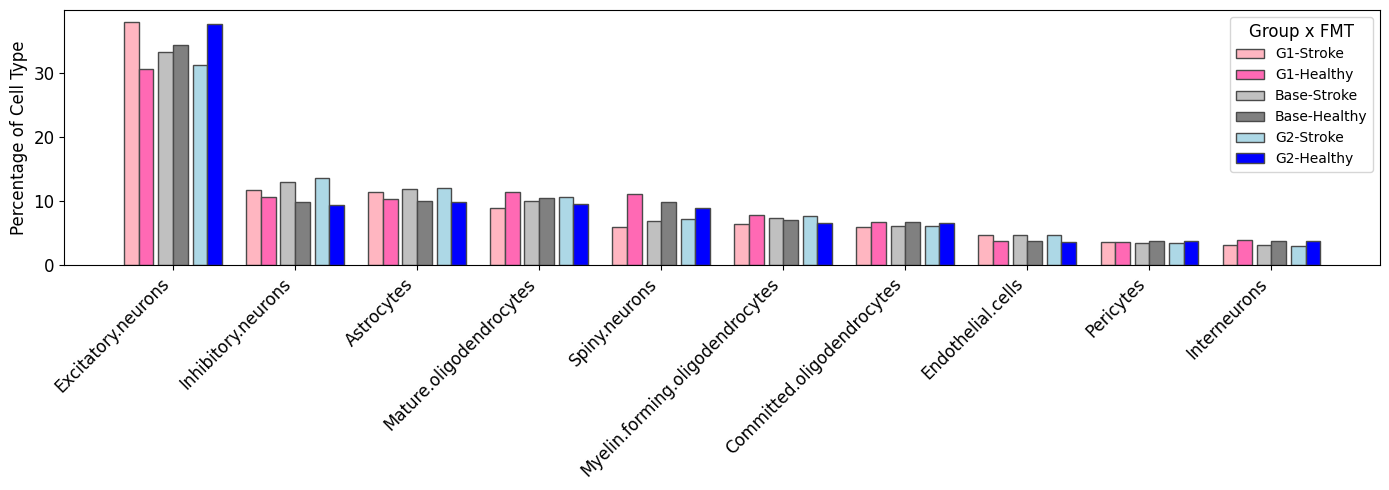

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

def plot_celltype_counts_per_FMT_trip(
    adata1,
    adata2,
    adata3, 
    top_n,
    label1="Up",
    label2="Down",
    label3="Base",
    fmt_cols=("Stroke_FMT", "Healthy_FMT"),
    colors=None,
    hatches=None,
    gap=0.1, 
    cell_type_key="ct_simple",  # <--- This argument was being ignored before
    annotate_significance=True,
    alpha=0.05,
    fig_size=(14,10)
):
    """
    Plot 6 bars per cell type with significance testing for 1vs2, 2vs3, and 1vs3.
    """

    ds1 = adata1.copy()
    ds2 = adata2.copy()
    ds3 = adata3.copy()

    # 1. Raw counts (FIXED: Uses cell_type_key variable instead of hardcoded string)
    counts1 = ds1.obs.groupby(["FMT", cell_type_key]).size()
    counts2 = ds2.obs.groupby(["FMT", cell_type_key]).size()
    counts3 = ds3.obs.groupby(["FMT", cell_type_key]).size()

    # 2. Totals
    total1_by_fmt = counts1.groupby(level="FMT").sum()
    total2_by_fmt = counts2.groupby(level="FMT").sum()
    total3_by_fmt = counts3.groupby(level="FMT").sum()

    # 3. Top N selection
    # Note: We align the series first to ensure matching indices before summing
    combined_counts = (
        counts1.add(counts2, fill_value=0).add(counts3, fill_value=0)
        .groupby(level=cell_type_key).sum()
    )
    top_clusters = combined_counts.nlargest(top_n).index

    # 4. Percent calc
    def _percent_df(counts):
        df = counts.unstack(level="FMT").fillna(0)
        for c in fmt_cols:
            if c not in df.columns:
                df[c] = 0.0
        df = df.reindex(index=top_clusters, columns=fmt_cols, fill_value=0)
        return df.div(df.sum(axis=0), axis=1) * 100

    df1 = _percent_df(counts1)
    df2 = _percent_df(counts2)
    df3 = _percent_df(counts3)

    # 5. Combined DataFrame
    col_names = [
        f"{label1}-Stroke", f"{label1}-Healthy",
        f"{label2}-Stroke", f"{label2}-Healthy",
        f"{label3}-Stroke", f"{label3}-Healthy",
    ]

    combined = pd.DataFrame({
        col_names[0]: df1[fmt_cols[0]],
        col_names[1]: df1[fmt_cols[1]],
        col_names[2]: df2[fmt_cols[0]],
        col_names[3]: df2[fmt_cols[1]],
        col_names[4]: df3[fmt_cols[0]],
        col_names[5]: df3[fmt_cols[1]],
    }, index=top_clusters)

    # 6. Setup Plot
    if colors is None:
        colors = [
            (249/255,100/255,149/255), (85/255,160/255,251/255), 
            "gold", "magenta", 
            "gray", "silver"
        ]
    if hatches is None:
        hatches = [""] * 6

    n = len(top_clusters)
    x = np.arange(n)
    bar_width = 0.12 
    
    # X Positions: G1(S,H) ... G2(S,H) ... G3(S,H)
    # Center is G2. 
    x_g2_s = x - (bar_width / 2)
    x_g2_h = x + (bar_width / 2)
    
    x_g1_h = x_g2_s - gap - (bar_width / 2)
    x_g1_s = x_g1_h - bar_width
    
    x_g3_s = x_g2_h + gap + (bar_width / 2)
    x_g3_h = x_g3_s + bar_width
    
    # List of X coordinates for easy indexing later: 0=G1S, 1=G1H, 2=G2S, 3=G2H, 4=G3S, 5=G3H
    x_coords_arrays = [x_g1_s, x_g1_h, x_g2_s, x_g2_h, x_g3_s, x_g3_h]

    fig, ax = plt.subplots(figsize=fig_size)

    # Draw Bars
    bars = []
    for k in range(6):
        b = ax.bar(x_coords_arrays[k], combined[col_names[k]], 
                   width=bar_width, color=colors[k], hatch=hatches[k], 
                   label=col_names[k], edgecolor='#4A4A4A')
        bars.append(b)
    
    ax.set_xticks(x)
    ax.set_xticklabels(top_clusters, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Percentage of Cell Type", fontsize=12)
    ax.legend(fontsize=10, title="Group x FMT", title_fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # 7. Significance Logic (Updated for 3-way comparisons)
    if annotate_significance:
        global_max_y = combined.values.max()
        vertical_step = 0.08 * global_max_y
        max_y_plotted = global_max_y

        def _p_to_stars(p):
            if p < 0.001: return "***"
            elif p < 0.01: return "**"
            elif p < 0.05: return "*"
            else: return ""

        # Define comparisons: (Label, DataA, TotalA, DataB, TotalB, GroupIdxA, GroupIdxB)
        # Group Indices: 1, 2, 3
        comparisons_config = [
            # Short brackets first (Pyramid stacking)
            ('1vs2', counts1, total1_by_fmt, counts2, total2_by_fmt, 1, 2),
            ('2vs3', counts2, total2_by_fmt, counts3, total3_by_fmt, 2, 3),
            # Long bracket last
            ('1vs3', counts1, total1_by_fmt, counts3, total3_by_fmt, 1, 3),
        ]

        for i, ct in enumerate(top_clusters):
            last_bracket_y = 0 
            
            for (comp_name, c_a, t_a, c_b, t_b, g_idx_a, g_idx_b) in comparisons_config:
                for j, fmt in enumerate(fmt_cols):
                    # j=0 Stroke, j=1 Healthy
                    
                    # Fisher Test
                    cnt_a = c_a.get((fmt, ct), 0)
                    cnt_b = c_b.get((fmt, ct), 0)
                    tot_a = t_a.get(fmt, 0)
                    tot_b = t_b.get(fmt, 0)
                    
                    if tot_a == 0 or tot_b == 0: continue
                    
                    try:
                        _, pval = fisher_exact([[cnt_a, tot_a - cnt_a], [cnt_b, tot_b - cnt_b]])
                    except:
                        continue
                        
                    if pval < alpha:
                        stars = _p_to_stars(pval)
                        
                        # Determine indices in the 0..5 bar list
                        # G1: S=0, H=1 | G2: S=2, H=3 | G3: S=4, H=5
                        idx_a = (g_idx_a - 1) * 2 + j
                        idx_b = (g_idx_b - 1) * 2 + j
                        
                        # Indices involved in the span (inclusive)
                        start_idx = min(idx_a, idx_b)
                        end_idx = max(idx_a, idx_b)
                        
                        # 1. Calculate max bar height in this span
                        span_heights = []
                        for k in range(start_idx, end_idx + 1):
                            span_heights.append(bars[k][i].get_height())
                        
                        max_bar_h = max(span_heights) if span_heights else 0
                        
                        # 2. Clearance logic
                        clearance = max_bar_h + (0.02 * global_max_y)
                        
                        # 3. Stack on top of previous brackets for this cluster
                        if clearance <= last_bracket_y:
                            y = last_bracket_y + vertical_step
                        else:
                            y = clearance
                        
                        # Update tracker
                        last_bracket_y = y
                        max_y_plotted = max(max_y_plotted, y)
                        
                        # Draw
                        x_left = x_coords_arrays[start_idx][i]
                        x_right = x_coords_arrays[end_idx][i]
                        
                        ax.plot([x_left, x_left, x_right, x_right],
                                [y - 0.01*global_max_y, y, y, y - 0.01*global_max_y],
                                color='black', linewidth=1.0)
                        
                        # Star text
                        ax.text((x_left + x_right) / 2, y + 0.01*global_max_y, stars,
                                ha="center", va="bottom", fontsize=10, color='black')

        ax.set_ylim(0, max_y_plotted * 1.15)

    plt.tight_layout()
    return ax

    plt.tight_layout()
    return ax
def plot_celltype_counts_per_FMT_pair(
    adata1,
    adata2,
    top_n,
    label1="Up",
    label2="Down",
    fmt_cols=("Stroke_FMT", "Healthy_FMT"),
    colors=None,
    hatches=None,
    cell_type_key="ct_simple",
    gap=0.25,
    annotate_significance=True,
    alpha=0.05
):
    """
    Plot 4 bars per cell type with a gap between Up and Down.
    Optionally compute significance (Fisher's exact test) comparing
    Up vs Down within each FMT for each cell type.
    """

    ds1 = adata1.copy()
    ds2 = adata2.copy()

    # raw counts per (FMT, cell_type)
    counts1 = ds1.obs.groupby(["FMT", cell_type_key]).size()
    counts2 = ds2.obs.groupby(["FMT", cell_type_key]).size()

    # total counts per FMT (for "other cell types" in contingency table)
    total1_by_fmt = counts1.groupby(level="FMT").sum()
    total2_by_fmt = counts2.groupby(level="FMT").sum()

    # choose shared top_n cell types
    combined_counts = (
        counts1.add(counts2, fill_value=0)
        .groupby(level=cell_type_key).sum()
    )
    top_clusters = combined_counts.nlargest(top_n).index

    # helper: convert to % within each FMT (same as before)
    def _percent_df(counts):
        df = counts.unstack(level="FMT").fillna(0)
        df = df.reindex(index=top_clusters, columns=fmt_cols, fill_value=0)
        return df.div(df.sum(axis=0), axis=1) * 100

    df1 = _percent_df(counts1)
    df2 = _percent_df(counts2)

    # combined % table
    col_names = [
        f"{label1}-Stroke", f"{label1}-Healthy",
        f"{label2}-Stroke", f"{label2}-Healthy",
    ]

    combined = pd.DataFrame({
        col_names[0]: df1[fmt_cols[0]],
        col_names[1]: df1[fmt_cols[1]],
        col_names[2]: df2[fmt_cols[0]],
        col_names[3]: df2[fmt_cols[1]],
    }, index=top_clusters)

    # colors
    if colors is None:
        colors = [
            (249/255,100/255,149/255),
            (85/255,160/255,251/255),
            "gold",
            "magenta"
        ]

    # hatches
    if hatches is None:
        hatches = ["", "", "", ""]

    # bar positions
    n = len(top_clusters)
    x = np.arange(n)
    bar_width = 0.18

    x_up_healthy  = x - bar_width - gap/2
    x_up_stroke = x - gap/2
    x_dn_healthy  = x + gap/2
    x_dn_stroke = x + bar_width + gap/2

    fig, ax = plt.subplots(figsize=(12, 5))

    b_up_stroke = ax.bar(
        x_up_stroke,
        combined[col_names[0]],
        width=bar_width,
        color=colors[0],
        hatch=hatches[0],
        label=col_names[0],
        edgecolor='#4A4A4A'
    )
    b_up_healthy = ax.bar(
        x_up_healthy,
        combined[col_names[1]],
        width=bar_width,
        color=colors[1],
        hatch=hatches[1],
        label=col_names[1],
        edgecolor='#4A4A4A'
    )
    b_dn_stroke = ax.bar(
        x_dn_stroke,
        combined[col_names[2]],
        width=bar_width,
        color=colors[2],
        hatch=hatches[2],
        label=col_names[2],
        edgecolor='#4A4A4A'
    )
    b_dn_healthy = ax.bar(
        x_dn_healthy,
        combined[col_names[3]],
        width=bar_width,
        color=colors[3],
        hatch=hatches[3],
        label=col_names[3],
        edgecolor='#4A4A4A'
    )

    # axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(top_clusters, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Percentage of Cell Type", fontsize=12)
    ax.legend(fontsize=10, title="Group × FMT", title_fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # ---------- Significance: Up vs Down within each FMT ----------
    if annotate_significance:
        ymax = combined.values.max()

        def _p_to_stars(p):
            if p < 0.001:
                return "***"
            elif p < 0.01:
                return "**"
            elif p < 0.05:
                return "*"
            else:
                return ""

        for i, ct in enumerate(top_clusters):
            # for each FMT: Stroke_FMT (index 0), Healthy_FMT (index 1)
            for j, fmt in enumerate(fmt_cols):
                # counts for this cell type and FMT in each dataset
                c1 = counts1.get((fmt, ct), 0)
                c2 = counts2.get((fmt, ct), 0)

                # total cells of that FMT in each dataset
                t1 = total1_by_fmt.get(fmt, 0)
                t2 = total2_by_fmt.get(fmt, 0)

                # if any zero totals, skip
                if t1 == 0 or t2 == 0:
                    continue

                # contingency:
                # [ [Up: this cell type, Up: others],
                #   [Down: this cell type, Down: others] ]
                table = [
                    [c1, t1 - c1],
                    [c2, t2 - c2]
                ]

                try:
                    _, pval = fisher_exact(table)
                except Exception:
                    continue

                if pval < alpha:
                    stars = _p_to_stars(pval)

                    # y position slightly above the taller of the two bars
                    if j == 0:  # Stroke
                        y1 = max(b_up_stroke[i].get_height(),b_up_healthy[i].get_height())
                        y2 = max(b_dn_stroke[i].get_height(),b_dn_healthy[i].get_height())
                        x1 = x_up_stroke[i]
                        x2 = x_dn_stroke[i]
                        offset = 0.03 * ymax
                        color_='black'
                    else:       # Healthy
                        y1 = max(b_up_stroke[i].get_height(),b_up_healthy[i].get_height())
                        y2 = max(b_dn_stroke[i].get_height(),b_dn_healthy[i].get_height())
                        x1 = x_up_healthy[i]
                        x2 = x_dn_healthy[i]
                        offset = 0.1 * ymax  # a bit higher to avoid overlap
                        color_='black'

                    y = max(y1, y2) + offset

                    # draw bracket
                    ax.plot([x1, x1, x2, x2],
                            [y - 0.01*ymax, y, y, y - 0.01*ymax],
                            color=color_, linewidth=1.0)

                    # add stars
                    ax.text(
                        (x1 + x2) / 2,
                        y + 0.01*ymax,
                        stars,
                        ha="center",
                        va="bottom",
                        fontsize=10,
                        color=color_
                    )

    plt.tight_layout()
    return ax
'''plot_celltype_counts_per_FMT_pair(
    cortex_up,
    cortex_down,
    top_n=16,
    label1="G1",
    label2="G2",
    hatches=["","","",""],
    colors=[
        (249/255, 100/255, 149/255),  # Up Stroke
        (85/255, 160/255, 251/255),   # Up Healthy
        #(249/255, 100/255, 149/255),  # Up Stroke
        #(85/255, 160/255, 251/255),  
        'gold',  # Up Stroke
        'magenta'
        ]
)'''
plot_celltype_counts_per_FMT_trip(
     cortex_up, 
     sub,
     cortex_down, 
    fig_size=[14,5],
     top_n=10,
     label1="G1", 
     label2="Base", 
     label3="G2",
     annotate_significance=False,
     colors=[
        #(249/255, 100/255, 149/255), # G1 S
        #(85/255, 160/255, 251/255),  # G1 H
        'lightpink',
        'hotpink',
        'silver',                      # G3 S (New)
        'grey',
        'lightblue',
        'blue'   
        #'gold',                      # G2 S
        #'magenta'
        ]
)


In [ ]:
adata

C:\Users\woods\AppData\Local\Temp\ipykernel_13696\825787619.py:103: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subset.obs['grouped_region'] = np.where(


Cerebellar cortex
Cerebral Nuclei, Striatum
Cortex
Fiber tract
Hippocampus
Hypothalamus
Midbrain, sensory related
Olfactory
Pons
Thalamus, polymodal association cortex related
medulla


C:\Users\woods\AppData\Local\Temp\ipykernel_13696\825787619.py:103: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subset.obs['grouped_region'] = np.where(


Cerebellar cortex
Cerebral Nuclei, Pallidum
Cerebral Nuclei, Striatum
Cortex
Fiber tract
Hippocampus
Midbrain, motor related
Midbrain, sensory related
Olfactory
Pons
Thalamus, polymodal association cortex related
Ventral group dorsal thalamus


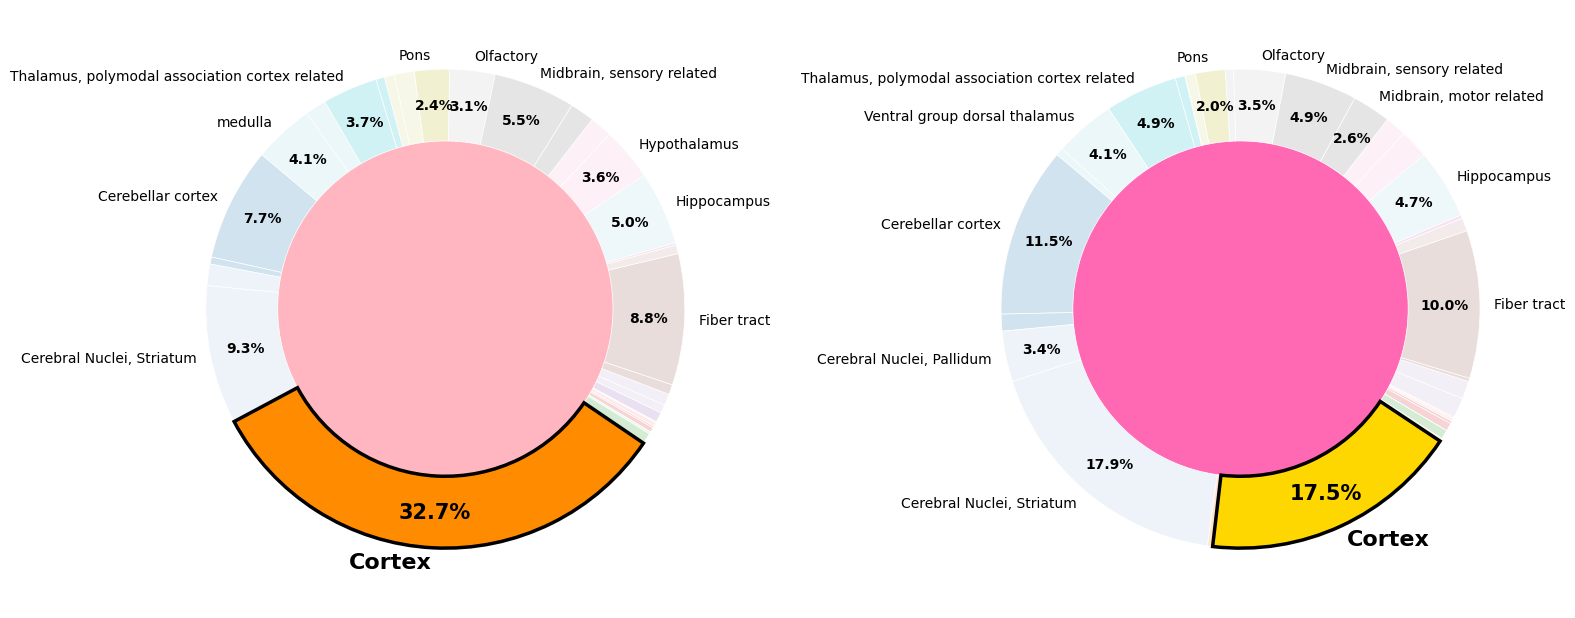

C:\Users\woods\AppData\Local\Temp\ipykernel_13696\825787619.py:103: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subset.obs['grouped_region'] = np.where(


Cerebellar cortex
Cerebral Nuclei, Striatum
Cortex
Fiber tract
Hippocampus
Hypothalamus
Midbrain, motor related
Midbrain, sensory related
Olfactory
Pons
Thalamus, polymodal association cortex related
medulla


C:\Users\woods\AppData\Local\Temp\ipykernel_13696\825787619.py:103: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subset.obs['grouped_region'] = np.where(


Cerebellar cortex
Cerebral Nuclei, Pallidum
Cerebral Nuclei, Striatum
Cortex
Fiber tract
Hippocampus
Midbrain, motor related
Midbrain, sensory related
Olfactory
Thalamus, polymodal association cortex related
Ventral group dorsal thalamus


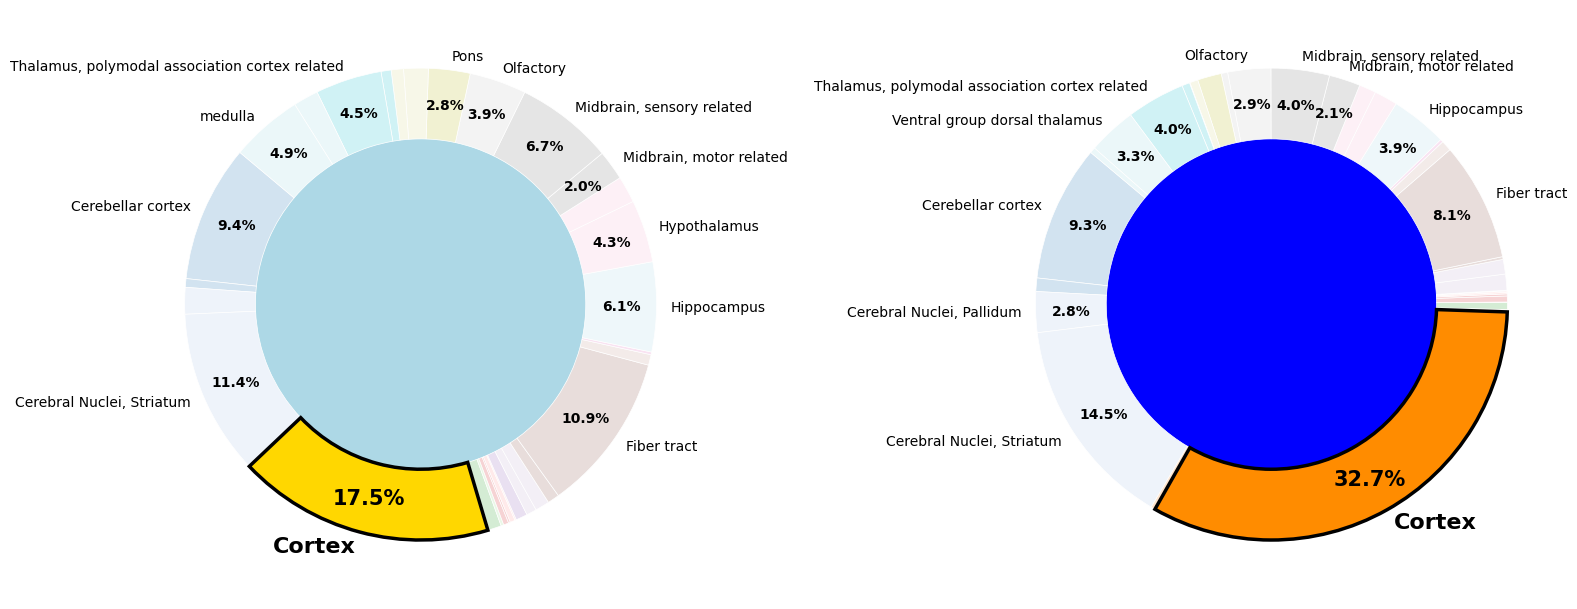

In [19]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# 1. CONFIGURATION
fmt_col = "FMT" 
region_col = "quint_region"
napari_col = "napari_region" # New reference for the grouping logic
adata_main= base_ad
# FIX: Access .obs for filtering
# Remove "coordinate-style" labels (e.g., "0,0,0")
coordinate_pattern = r'^\d+,\d+,\d+$'
mask_coords = adata_main.obs[region_col].astype(str).str.match(coordinate_pattern)
adata_full_clean = adata_main[~mask_coords].copy()

# 2. DEFINE GROUPING LOGIC
adata_full_clean.obs['grouped_region'] = np.where(
    adata_full_clean.obs[napari_col] == 'Cortex', 
    'Cortex', 
    adata_full_clean.obs[region_col]
)

unique_grouped_regions = sorted(adata_full_clean.obs['grouped_region'].unique().astype(str))

# 3. DYNAMIC COLOR PALETTE
fallback_palette = cm.tab20(np.linspace(0, 1, len(unique_grouped_regions)))
manual_overrides = {
    'Hippocampus': 'lightblue',
    'Cerebellum': 'lightgreen',
    'Unassigned': 'grey'
}

global_color_map = {}

for i, region in enumerate(unique_grouped_regions):
    if region == "Cortex":
        global_color_map[region] = 'placeholder'
    else:
        if region in manual_overrides:
            base = manual_overrides[region]
        else:
            base = fallback_palette[i]
        global_color_map[region] = mcolors.to_rgba(base, alpha=0.2)

# 4. PLOTTING CONFIG
rows_config = [
    (0, up, "G1: Stroke Cortex Enriched"),
    (1, down, "G2: Healthy Cortex Enriched")
]

cols_config = [
    (0, "Stroke_FMT"),
    (1, "Healthy_FMT")
]

# --- HELPER FUNCTION FOR LABELS ---
def get_clean_labels(counts, threshold=2.0):
    total = counts.sum()
    labels_list = []
    autopct_list = []
    
    for name, val in counts.items():
        pct = (val / total) * 100
        if pct >= threshold:
            labels_list.append(name)
            autopct_list.append(f"{pct:.1f}%")
        else:
            labels_list.append("") 
            autopct_list.append("")
            
    return labels_list, autopct_list


# --- NEW: LOOP GENERATES SEPARATE FIGURES FOR EACH ROW ---
for row_idx, adata_obj, manip_name in rows_config:
    
    # Create a new 1x2 figure just for this row
    fig, axes = plt.subplots(1, 2, figsize=(16, 8)) 
    
    # PRE-CALCULATE CORTEX PERCENTAGES FOR THIS ROW
    cortex_pcts = {}
    for col_idx, fmt_group in cols_config:
        subset = adata_obj[adata_obj.obs[fmt_col] == fmt_group]
        mask = ~subset.obs[region_col].astype(str).str.match(coordinate_pattern)
        valid_napari = subset.obs[napari_col][mask]
        
        total_cells = len(valid_napari)
        cortex_cells = (valid_napari == 'Cortex').sum()
        cortex_pcts[fmt_group] = (cortex_cells / total_cells) * 100 if total_cells > 0 else 0
        
    higher_cortex_fmt = max(cortex_pcts, key=cortex_pcts.get)
    
    for col_idx, fmt_group in cols_config:
        
        # Access the 1D axes array
        ax = axes[col_idx]
        
        subset = adata_obj[adata_obj.obs[fmt_col] == fmt_group].copy()
        subset = subset[~subset.obs[region_col].astype(str).str.match(coordinate_pattern)]
        
        subset.obs['grouped_region'] = np.where(
            subset.obs[napari_col] == 'Cortex', 
            'Cortex', 
            subset.obs[region_col]
        )
        
        counts = subset.obs['grouped_region'].value_counts().sort_index()
        
        # DYNAMIC, VIVID COLORS FOR CORTEX
        current_colors = []
        for r in counts.index:
            if r == "Cortex":
                if fmt_group == higher_cortex_fmt:
                    current_colors.append('#FF8C00') # Vivid Dark Orange/Gold
                else:
                    current_colors.append('#FFD700') # Bright Vivid Gold
            else:
                current_colors.append(global_color_map.get(str(r), 'lightgrey'))
        
        clean_labels, clean_autopct = get_clean_labels(counts, threshold=2.0)

        # Plot using native donut width
        wedges, texts, autotexts = ax.pie(
            counts,
            labels=clean_labels, 
            autopct='%1.1f%%',   
            colors=current_colors,
            startangle=140,
            pctdistance=0.85, 
            labeldistance=1.06, # Increased slightly to give outer text more breathing room
            wedgeprops={'width': 0.30}  
        )
        

        for i, wedge in enumerate(wedges):
            if clean_labels[i] == "Cortex":
                wedge.set_edgecolor('black')
                wedge.set_linewidth(2.5) 
                wedge.set_zorder(10)     
            else:
                wedge.set_edgecolor('white')
                wedge.set_linewidth(0.5)
                wedge.set_zorder(1)

        for i, t in enumerate(texts):
            t.set_zorder(15)
            if clean_labels[i] == "Cortex":
                t.set_fontsize(16)       
                t.set_fontweight('bold') 
            else:
                t.set_fontsize(10)
                
        # Styling text (percentages) and bringing to the front
        for i, t in enumerate(autotexts):
            t.set_zorder(15) 
            t.set_text(clean_autopct[i])
            if clean_autopct[i] != "":
    
                t.set_fontweight('bold')
                t.set_color('black') 
                print(clean_labels[i])
                if clean_labels[i] == "Cortex":
                    t.set_fontsize(15)       # <-- Makes the Cortex label larger

                else:
                    t.set_fontsize(10)     

        # DYNAMIC DONUT HOLE COLOR
        donut_color = ['hotpink','blue']  if fmt_group == 'Healthy_FMT' else ['lightpink','lightblue']
        centre_circle = plt.Circle((0,0), 0.70, fc=donut_color[row_idx], zorder=0)
        ax.add_artist(centre_circle)
        
       
    plt.tight_layout()
    # Save dynamically based on the row name if needed:
    # plt.savefig(f"Cortex_Enrichment_{row_idx}.png", dpi=300, bbox_inches='tight')
    plt.show() # Renders the current row before looping to the next